# Part 3: Image Denoising and Wiener Filtering

This notebook addresses synthetic noise injection, noise variance estimation, spatial filtering (mean and median), and frequency-domain Wiener filtering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import io
from PIL import Image

# Common function to calculate PSNR
def calculate_psnr(original, restored):
    mse = np.mean((original - restored) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255.0 ** 2) / mse)


### 1. Image Acquisition and Synthetic Noise Injection

A reference image from the Kodak image suite is acquired and converted to grayscale. Synthetic Gaussian noise is injected such that the Peak Signal-to-Noise Ratio (PSNR) is exactly 20 dB. The noisy image intensity values are permitted to exceed the standard [0, 255] boundary.

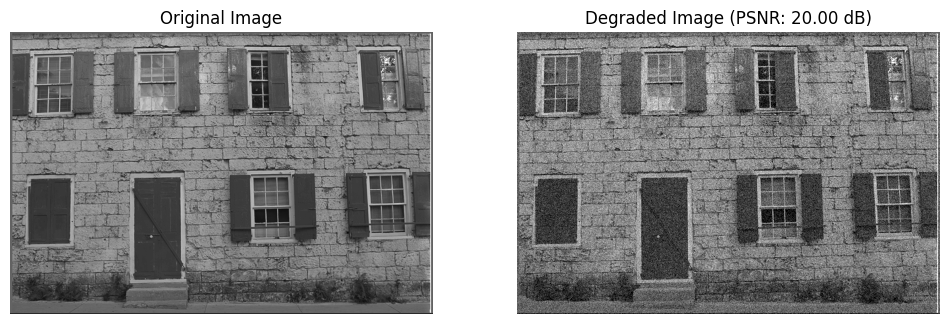

True Noise Variance: 650.25
True Noise Standard Deviation: 25.50


In [2]:
import os
# Try to load locally first, otherwise fetch from the Kodak image suite
local_path = "kodim01.png"
original_image_pil = Image.open(local_path).convert('L')


original_image = np.asarray(original_image_pil, dtype=np.float64)

# Calculate required noise variance for PSNR = 20 dB
# PSNR = 10 * log10(MAX^2 / MSE) -> 20 = 10 * log10(255^2 / variance)
# variance = 255^2 / 100
true_variance = (255.0 ** 2) / 100.0
true_sigma = np.sqrt(true_variance)

# Generate and add Gaussian noise
np.random.seed(42) # For reproducibility
noise = np.random.randn(*original_image.shape) * true_sigma
degraded_image = original_image + noise

psnr_degraded = calculate_psnr(original_image, degraded_image)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(degraded_image, cmap='gray', vmin=0, vmax=255)
plt.title(f"Degraded Image (PSNR: {psnr_degraded:.2f} dB)")
plt.axis('off')
plt.show()

print(f"True Noise Variance: {true_variance:.2f}")
print(f"True Noise Standard Deviation: {true_sigma:.2f}")



### 2. Blind Noise Variance Estimation

In the absence of a priori knowledge regarding the noise statistics, the noise variance must be estimated directly from the degraded image. A computationally efficient and robust estimation method involves partitioning the image into non-overlapping spatial blocks and calculating the variance within each block. Under the assumption that the image contains at least one completely smooth, textureless region, the intrinsic spatial variance of that optimal region approaches zero. Consequently, the minimum variance observed across all blocks serves as an effective empirical estimate of the global noise variance.

In [3]:
def estimate_noise_variance(image, block_size=16):
    rows, cols = image.shape
    min_var = float('inf')
    
    # Iterate through non-overlapping blocks
    for i in range(0, rows - block_size + 1, block_size):
        for j in range(0, cols - block_size + 1, block_size):
            block = image[i:i+block_size, j:j+block_size]
            block_var = np.var(block)
            if block_var < min_var:
                min_var = block_var
                
    return min_var

estimated_variance = estimate_noise_variance(degraded_image, block_size=16)

print(f"True Noise Variance: {true_variance:.2f}")
print(f"Estimated Noise Variance: {estimated_variance:.2f}")
print(f"Estimation Error: {abs(true_variance - estimated_variance):.2f}")


True Noise Variance: 650.25
Estimated Noise Variance: 474.33
Estimation Error: 175.92


### 3. Spatial Filtering (Mean and Median)

The degraded image is subjected to spatial denoising using $m \times m$ arithmetic mean and median filters. To avoid external high-level image processing libraries, vectorized spatial window extraction is utilized.

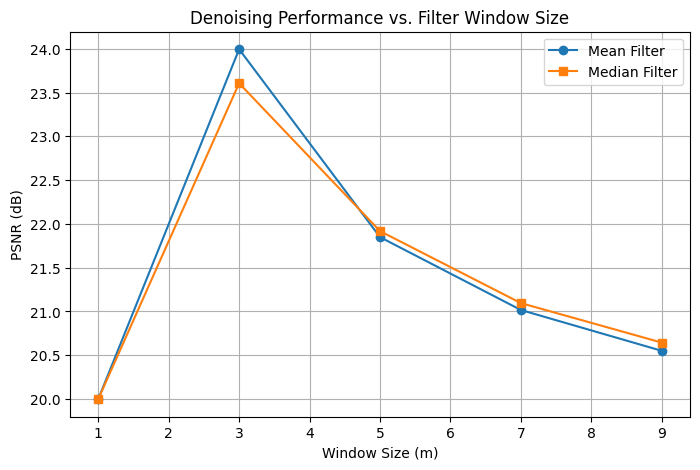

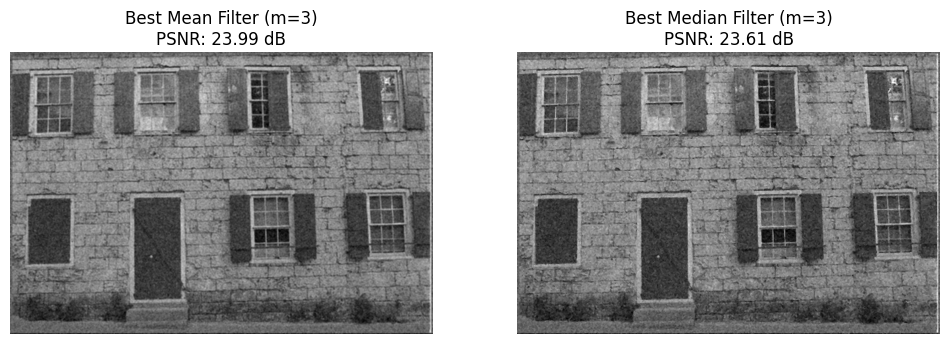

In [4]:
from numpy.lib.stride_tricks import sliding_window_view

def apply_spatial_filter(img, m, filter_type='mean'):
    if m == 1:
        return img.copy()
        
    pad_w = m // 2
    # Apply symmetric padding to handle boundary conditions
    padded = np.pad(img, pad_w, mode='symmetric')
    
    # Extract sliding windows efficiently using numpy stride tricks
    windows = sliding_window_view(padded, (m, m))
    
    if filter_type == 'mean':
        return np.mean(windows, axis=(2, 3))
    elif filter_type == 'median':
        return np.median(windows, axis=(2, 3))
    else:
        raise ValueError("Unsupported filter type.")

window_sizes = [1, 3, 5, 7, 9]
psnr_mean = []
psnr_median = []
best_mean_img = None
best_median_img = None
max_psnr_mean = -1
max_psnr_median = -1
best_m_mean = 1
best_m_median = 1

for m in window_sizes:
    # Mean Filter
    restored_mean = apply_spatial_filter(degraded_image, m, filter_type='mean')
    p_mean = calculate_psnr(original_image, restored_mean)
    psnr_mean.append(p_mean)
    if p_mean > max_psnr_mean:
        max_psnr_mean = p_mean
        best_mean_img = restored_mean
        best_m_mean = m
        
    # Median Filter
    restored_median = apply_spatial_filter(degraded_image, m, filter_type='median')
    p_median = calculate_psnr(original_image, restored_median)
    psnr_median.append(p_median)
    if p_median > max_psnr_median:
        max_psnr_median = p_median
        best_median_img = restored_median
        best_m_median = m

# Plotting PSNR vs Window Size
plt.figure(figsize=(8, 5))
plt.plot(window_sizes, psnr_mean, marker='o', label='Mean Filter')
plt.plot(window_sizes, psnr_median, marker='s', label='Median Filter')
plt.xlabel('Window Size (m)')
plt.ylabel('PSNR (dB)')
plt.title('Denoising Performance vs. Filter Window Size')
plt.grid(True)
plt.legend()
plt.show()

# Display Best Restored Images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(best_mean_img, cmap='gray', vmin=0, vmax=255)
plt.title(f"Best Mean Filter (m={best_m_mean})\nPSNR: {max_psnr_mean:.2f} dB")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(best_median_img, cmap='gray', vmin=0, vmax=255)
plt.title(f"Best Median Filter (m={best_m_median})\nPSNR: {max_psnr_median:.2f} dB")
plt.axis('off')
plt.show()


**Analysis of PSNR Dynamics with Respect to Filter Size:**
The spatial filters operate by aggregating local neighborhood information. Initially, increasing the spatial window size $m$ incorporates more neighborhood samples, effectively averaging out the zero-mean independent Gaussian noise. This substantially reduces the noise variance and yields an increase in the PSNR. However, as $m$ continues to expand, the filters process increasingly heterogeneous spatial regions, resulting in the progressive blurring of high-frequency structural details (such as edges and textures). Eventually, the structural degradation penalty outweighs the noise reduction benefits, causing the Mean Squared Error (MSE) to rise and the overall PSNR to decline.


### 4. Custom 2D FFT Implementation

Frequency-domain operations require a custom implementation of the Fast Fourier Transform (FFT).

In [5]:
def fft1d(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N == 1:
        return x.copy()
    if N & (N - 1):
        raise ValueError("Length must be power of 2")
    X_even = fft1d(x[::2])
    X_odd = fft1d(x[1::2])
    k = np.arange(N // 2)
    W = np.exp(-2j * np.pi * k / N)
    X = np.zeros(N, dtype=complex)
    X[:N//2] = X_even + W * X_odd
    X[N//2:] = X_even - W * X_odd
    return X

def ifft1d(X):
    X = np.asarray(X, dtype=complex)
    N = len(X)
    return np.conj(fft1d(np.conj(X))) / N

def fft2d(image):
    image = np.asarray(image, dtype=complex)
    rows, cols = image.shape
    temp = np.zeros((rows, cols), dtype=complex)
    for i in range(rows):
        temp[i, :] = fft1d(image[i, :])
    result = np.zeros((rows, cols), dtype=complex)
    for j in range(cols):
        result[:, j] = fft1d(temp[:, j])
    return result

def ifft2d(F):
    F = np.asarray(F, dtype=complex)
    rows, cols = F.shape
    temp = np.zeros((rows, cols), dtype=complex)
    for i in range(rows):
        temp[i, :] = ifft1d(F[i, :])
    result = np.zeros((rows, cols), dtype=complex)
    for j in range(cols):
        result[:, j] = ifft1d(temp[:, j])
    return result

def next_power_of_two(n):
    return 1 if n == 1 else 2 ** int(np.ceil(np.log2(n)))

def pad_to_power_of_two(image):
    rows, cols = image.shape
    new_rows = next_power_of_two(rows)
    new_cols = next_power_of_two(cols)
    padded = np.zeros((new_rows, new_cols), dtype=float)
    padded[:rows, :cols] = image
    return padded

### 5. Wiener Filtering for Denoising

The Wiener filter minimizes the mean square error between the estimated image and the true image. In the frequency domain, the Wiener filter transfer function without blur is formulated as:

$W(u,v) = \frac{S_f(u,v)}{S_f(u,v) + S_\eta(u,v)} = \frac{1}{1 + \frac{S_\eta(u,v)}{S_f(u,v)}}$

where $S_f$ and $S_\eta$ represent the power spectral densities of the image and the noise, respectively.

#### Constant Power Spectral Density Ratio Assumption
When the ratio $S_\eta / S_f$ is strictly assumed to be a global constant $K$, the transfer function simplifies to $W(u,v) = \frac{1}{1 + K}$. Under this assumption, the filter operates purely as a uniform scalar multiplier. A parameter sweep identifies the optimal constant.


In [6]:
# Pad the degraded image for custom FFT
degraded_padded = pad_to_power_of_two(degraded_image)
orig_rows, orig_cols = degraded_image.shape

# Transform the degraded image into the frequency domain
G_padded = fft2d(degraded_padded)

# Test multiple constant values for K to locate the optimum PSNR empirically
test_Ks = np.logspace(-3, 1, 50)
best_K = None
best_constant_wiener_psnr = -1
best_constant_wiener_img = None

for K in test_Ks:
    # Apply uniform transfer function W(u,v) = 1 / (1 + K)
    W_constant = 1.0 / (1.0 + K)
    F_hat_padded = G_padded * W_constant
    
    # Inverse transform and crop
    f_hat_padded = np.real(ifft2d(F_hat_padded))
    f_hat = f_hat_padded[:orig_rows, :orig_cols]
    
    current_psnr = calculate_psnr(original_image, f_hat)
    if current_psnr > best_constant_wiener_psnr:
        best_constant_wiener_psnr = current_psnr
        best_constant_wiener_img = f_hat
        best_K = K

print(f"Optimal Constant K: {best_K:.4f}")
print(f"Best Constant Wiener PSNR: {best_constant_wiener_psnr:.2f} dB")


Optimal Constant K: 0.0518
Best Constant Wiener PSNR: 20.20 dB


#### Frequency-Dependent Estimate
A robust frequency-dependent estimate leverages the expected noise power spectrum. For Gaussian white noise, $\mathbb{E}(|N[u,v]|^2) \approx M N \sigma^2$, where $M, N$ correspond to the spatial dimensions of the padded image. The image power spectrum is approximated via spectral subtraction: 

$\mathbb{E}(|F[u,v]|^2) \approx \max(|G[u,v]|^2 - \mathbb{E}(|N[u,v]|^2), 0)$

Substituting this into the Wiener filter formulation yields a frequency-adaptive filter that attenuates frequency bins selectively based on their localized signal-to-noise ratio.


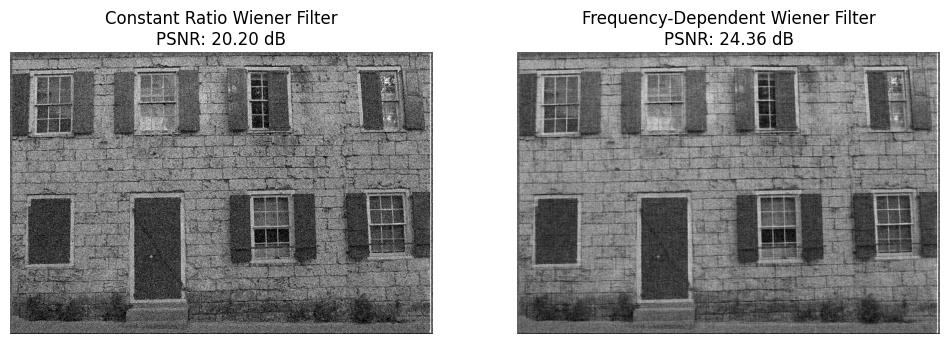

In [7]:
padded_rows, padded_cols = degraded_padded.shape
M, N = padded_rows, padded_cols

# Compute expected noise power spectrum
expected_noise_power = M * N * true_variance

# Compute magnitude squared of the degraded spectrum
G_power = np.abs(G_padded) ** 2

# Estimate original image power spectrum via spectral subtraction
estimated_F_power = np.maximum(G_power - expected_noise_power, 0.0)

# Construct the frequency-dependent Wiener filter transfer function
# Small epsilon prevents division by zero
W_adaptive = estimated_F_power / (estimated_F_power + expected_noise_power + 1e-10)

# Apply adaptive Wiener filter
F_hat_adaptive_padded = G_padded * W_adaptive

# Inverse transform and crop to original dimensions
f_hat_adaptive_padded = np.real(ifft2d(F_hat_adaptive_padded))
f_hat_adaptive = f_hat_adaptive_padded[:orig_rows, :orig_cols]

adaptive_wiener_psnr = calculate_psnr(original_image, f_hat_adaptive)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(best_constant_wiener_img, cmap='gray', vmin=0, vmax=255)
plt.title(f"Constant Ratio Wiener Filter\nPSNR: {best_constant_wiener_psnr:.2f} dB")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(f_hat_adaptive, cmap='gray', vmin=0, vmax=255)
plt.title(f"Frequency-Dependent Wiener Filter\nPSNR: {adaptive_wiener_psnr:.2f} dB")
plt.axis('off')

plt.show()
